# Función de distribución inicial de una ley de potencia

Comparamos la expresión de Gondolo–Silk con la inversión directa de `dm_spikes.eddington`. Ambas evaluaciones emplean la misma densidad, el mismo potencial **confinante** y la misma energía mecánica positiva. El parámetro $\gamma$ puede cambiarse en la siguiente celda ($0<\gamma<2$).

$$\rho(r)=\rho_D\left(\frac{r}{r_D}\right)^{-\gamma},\qquad \phi_0(r)=B\left(\frac{r}{r_D}\right)^{2-\gamma},$$
$$r_D=D=8.5\times10^3\,\mathrm{pc},\qquad \rho_D=0.0062\left(1-\frac{\gamma}{3}\right)\,M_\odot\,\mathrm{pc}^{-3},$$
$$B=\frac{4\pi G\rho_Dr_D^2}{(3-\gamma)(2-\gamma)},\qquad \beta=\frac{6-\gamma}{2(2-\gamma)}.$$

Se usa $G=4.30091\times10^{-3}\,\mathrm{pc}\,(\mathrm{km/s})^2/M_\odot$, igual que en el proyecto. Por ello $B$ y $E$ están en $(\mathrm{km/s})^2$.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy.special import gammaln

src_path = Path.cwd() / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from dm_spikes.eddington import make_eddington_df

gamma = 1.0  # Cambiar aquí: 0 < gamma < 2
if not 0.0 < gamma < 2.0:
    raise ValueError("gamma debe cumplir 0 < gamma < 2")

D = 8.5e3  # pc
G = 4.30091e-3  # pc (km/s)^2 / Msun
r_D = D
rho_D = 0.0062 * (1.0 - gamma / 3.0)  # Msun / pc^3
B = 4.0 * np.pi * G * rho_D * r_D**2 / ((3.0 - gamma) * (2.0 - gamma))
beta = (6.0 - gamma) / (2.0 * (2.0 - gamma))

def density(radius):
    return rho_D * (radius / r_D) ** (-gamma)

def potential(radius):
    return B * (radius / r_D) ** (2.0 - gamma)

energy_over_B = np.logspace(-2.0, 2.0, 120)
energy = B * energy_over_B
print(f"gamma={gamma:g}; r_D={r_D:g} pc; rho_D={rho_D:.8g} Msun/pc^3; B={B:.8g} (km/s)^2")

gamma=1; r_D=8500 pc; rho_D=0.0041333333 Msun/pc^3; B=8070.0924 (km/s)^2


## 1. Distribución analítica

Para $E>0$ usamos directamente la fórmula proporcionada:

$$f_{\mathrm{GS}}(E)=\frac{\rho_D}{(2\pi B)^{3/2}}\frac{\Gamma(\beta)}{\Gamma(\beta-3/2)}\left(\frac{B}{E}\right)^\beta.$$

Se evalúa en logaritmos para evitar desbordamientos de la función gamma cuando $\gamma$ se acerca a 2.

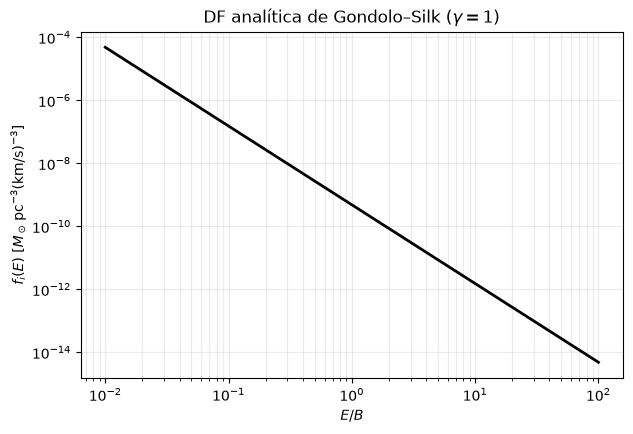

In [2]:
log_df_analytic = (
    np.log(rho_D) - 1.5 * np.log(2.0 * np.pi * B)
    + gammaln(beta) - gammaln(beta - 1.5)
    - beta * np.log(energy_over_B)
)
df_analytic = np.exp(log_df_analytic)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(energy_over_B, df_analytic, color="black", lw=2)
ax.set(xlabel=r"$E/B$", ylabel=r"$f_i(E)$ [$M_\odot\,\mathrm{pc}^{-3}(\mathrm{km/s})^{-3}$]",
       title=rf"DF analítica de Gondolo–Silk ($\gamma={gamma:g}$)")
ax.grid(True, which="both", alpha=0.25)
plt.show()

## 2. Distribución obtenida con el módulo

La siguiente celda construye $f_i(E)$ **sin emplear la fórmula analítica**: solo proporciona $\rho(r)$, $\phi_0(r)$ y `"confining"` a `make_eddington_df`. La función devuelta se evalúa punto por punto porque su interfaz energética es escalar.

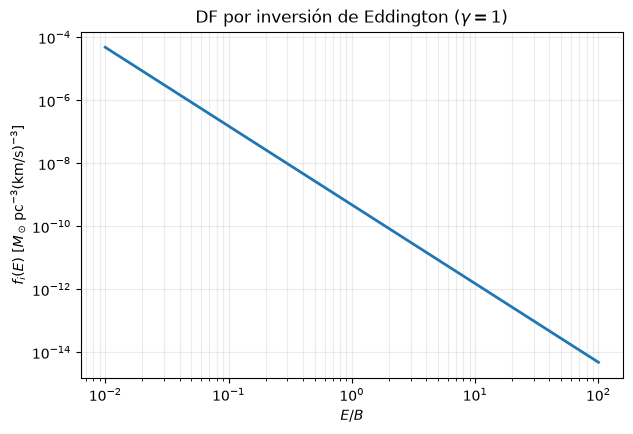

In [3]:
df_initial = make_eddington_df(density, potential, "confining")
df_numerical = np.array([df_initial(float(E)) for E in energy])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(energy_over_B, df_numerical, color="tab:blue", lw=2)
ax.set(xlabel=r"$E/B$", ylabel=r"$f_i(E)$ [$M_\odot\,\mathrm{pc}^{-3}(\mathrm{km/s})^{-3}$]",
       title=rf"DF por inversión de Eddington ($\gamma={gamma:g}$)")
ax.grid(True, which="both", alpha=0.25)
plt.show()

## 3. Superposición

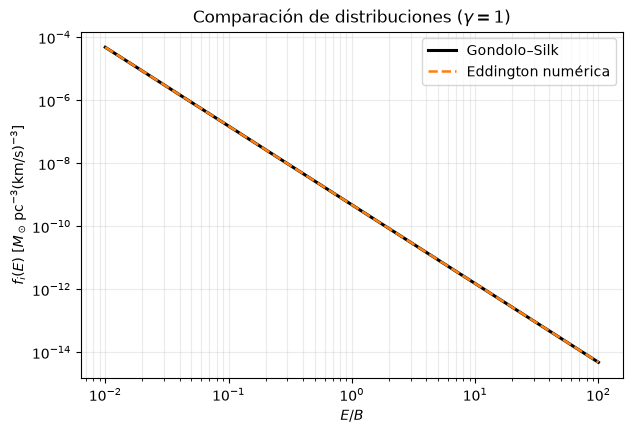

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(energy_over_B, df_analytic, color="black", lw=2.2, label="Gondolo–Silk")
ax.loglog(energy_over_B, df_numerical, color="tab:orange", lw=1.8, ls="--", label="Eddington numérica")
ax.set(xlabel=r"$E/B$", ylabel=r"$f_i(E)$ [$M_\odot\,\mathrm{pc}^{-3}(\mathrm{km/s})^{-3}$]",
       title=rf"Comparación de distribuciones ($\gamma={gamma:g}$)")
ax.legend()
ax.grid(True, which="both", alpha=0.25)
plt.show()

## 4. Error relativo

Definimos $\delta(E)=|f_{\mathrm{Eddington}}(E)-f_{\mathrm{GS}}(E)|/f_{\mathrm{GS}}(E)$.

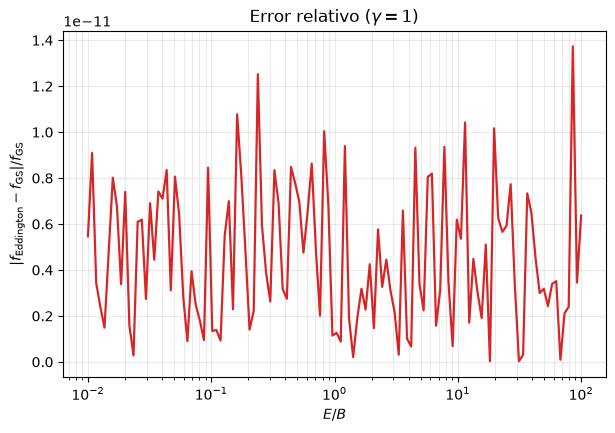

Error relativo máximo en la malla: 1.374e-11


In [5]:
relative_error = np.abs(df_numerical - df_analytic) / df_analytic

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(energy_over_B, relative_error, color="tab:red", lw=1.6)
ax.set_xscale("log")
ax.set(xlabel=r"$E/B$", ylabel=r"$|f_{\mathrm{Eddington}}-f_{\mathrm{GS}}|/f_{\mathrm{GS}}$",
       title=rf"Error relativo ($\gamma={gamma:g}$)")
ax.grid(True, which="both", alpha=0.25)
plt.show()
print(f"Error relativo máximo en la malla: {relative_error.max():.3e}")